# Cap. 03 — Introducción a los Algoritmos Cuánticos
## Listing 3-12: Algoritmo de Grover (Qiskit)

**Referencia:** Pattanayak, *Quantum Machine Learning with Python*, Capítulo 3, Listing 3-12.  
Implementación equivalente en Qiskit del notebook Cirq `10_grovers_algorithm.ipynb`.

Esta versión está **generalizada para $n$ qubits** y demuestra el algoritmo con:
- $n = 2$ ($N = 4$ elementos, 1 iteración) — caso del libro
- $n = 3$ ($N = 8$ elementos, 2 iteraciones) — oráculo más complejo con `mcx`

---

### Resumen del algoritmo

Grover busca un elemento marcado en una base de datos de $N = 2^n$ elementos con $O(\sqrt{N})$ consultas al oráculo — aceleración cuadrática sobre cualquier búsqueda clásica.

| Paso | Acción |
|---|---|
| 1 | Preparar superposición uniforme $\vert \psi_{\text{eq}}\rangle$ con H en $n$ qubits de entrada + qubit ancilla en $\vert -\rangle$ |
| 2 | **Oráculo** $U_f$: marca el ganador con fase $-1$ vía phase kickback |
| 3 | **Difusor** $U_{\psi}$: reflexión sobre $\vert \psi_{\text{eq}}\rangle$ — amplifica la amplitud del ganador |
| 4 | Repetir pasos 2-3 un total de $m \approx \frac{\pi}{4}\sqrt{N}$ veces |
| 5 | Medir los qubits de entrada |

### Número óptimo de iteraciones

| $n$ | $N = 2^n$ | $m$ iteraciones | $P(\text{ganador})$ |
|:---:|:---:|:---:|:---:|
| 2 | 4 | 1 | 100% |
| 3 | 8 | 2 | ~94.5% |
| 4 | 16 | 3 | ~96% |
| 10 | 1024 | 25 | ~96% |

### Diferencias de API respecto al libro (Qiskit 1.0+)

| Libro / Cirq | Este notebook (Qiskit ≥1.0) |
|---|---|
| `cirq.TOFFOLI(*inputs, target)` | `circuit.mcx(controls, target)` — funciona con $n \geq 2$ controles |
| `cirq.H.on_each(*qubits)` | `circuit.h(range(n))` |
| `from qiskit import execute, Aer` | `from qiskit_aer import AerSimulator` |
| Difusor hardcodeado para 2 qubits | Difusor generalizado con `mcx` |

---

## Explicación profunda del algoritmo

### 1. El oráculo generalizado

Para buscar el elemento ganador $\vert k\rangle$ en $n$ qubits:

1. **Convertir $\vert k\rangle$ a $\vert 11\ldots 1\rangle$**: aplicar X en cada qubit cuyo bit correspondiente en $k$ sea 0.  
   Ejemplo: buscar $\vert 011\rangle$ en 3 qubits → aplicar X en Q0 (el primer bit es 0).
2. **Multi-controlled NOT (MCX)**: con todos los qubits de entrada como control y el qubit ancilla (en $\vert -\rangle$) como blanco. Solo dispara cuando **todos** los controles son 1 — es decir, solo cuando el estado es el ganador convertido.
3. **Deshacer las X** del paso 1.

En Qiskit, `circuit.mcx(controls, target)` generaliza el Toffoli a $n$ controles automáticamente.

### 2. El difusor generalizado

El difusor implementa $U_{\psi} = 2\vert \psi_{\text{eq}}\rangle\langle \psi_{\text{eq}}\vert - I$:

```
H⊗n → X⊗n → H(último) → MCX(primeros → último) → H(último) → X⊗n → H⊗n
```

El bloque `H · MCX · H` en el último qubit implementa un multi-controlled Z, que aplica fase $-1$ solo al estado $\vert 11\ldots 1\rangle$. Combinado con las X y H circundantes, esto refleja sobre la superposición uniforme.

### 3. La interpretación geométrica

El estado vive en un plano 2D formado por $\vert k\rangle$ (ganador) y $\vert c\rangle$ (no ganadores):

$$\vert \psi_{\text{eq}}\rangle = \sin\theta\,\vert k\rangle + \cos\theta\,\vert c\rangle, \quad \sin\theta = \frac{1}{\sqrt{N}}$$

Cada iteración rota $2\theta$ hacia el ganador:

| $N$ | $\theta$ | Rotación por iteración | $m$ para $\approx 90°$ |
|:---:|:---:|:---:|:---:|
| 4 | 30° | 60° | 1 |
| 8 | 20.7° | 41.4° | 2 |
| 16 | 14.5° | 29° | 3 |

---
## Implementación generalizada para $n$ qubits

### Oráculo

In [18]:
import math

import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator


def oracle(circuit, input_qubits, target_qubit, secret_element):
    """
    Oráculo de Grover: marca |secret_element⟩ con fase -1.

    1. X en qubits con bit 0 → convierte el ganador a |11...1⟩
    2. MCX(inputs → target) → dispara solo para |11...1⟩
    3. Deshace las X
    """
    for i, bit in enumerate(secret_element):
        if int(bit) == 0:
            circuit.x(input_qubits[i])

    circuit.mcx(input_qubits, target_qubit)

    for i, bit in enumerate(secret_element):
        if int(bit) == 0:
            circuit.x(input_qubits[i])

### Difusor

Implementa $U_{\psi} = H^{\otimes n}(2\vert 0\rangle^n\langle 0\vert^n - I)H^{\otimes n}$ con puertas estándar.

In [19]:
def diffuser(circuit, input_qubits):
    """
    Difusor de Grover generalizado para n qubits.

    H⊗n → X⊗n → H(último) → MCX(primeros → último) → H(último) → X⊗n → H⊗n
    """
    n = len(input_qubits)
    circuit.h(input_qubits)
    circuit.x(input_qubits)

    # Multi-controlled Z = H · MCX · H en el último qubit
    circuit.h(input_qubits[-1])
    circuit.mcx(input_qubits[:-1], input_qubits[-1])
    circuit.h(input_qubits[-1])

    circuit.x(input_qubits)
    circuit.h(input_qubits)

### Algoritmo completo

In [20]:
def grovers_algorithm(num_qubits=2, copies=1000, secret_element='01'):
    """
    Algoritmo de Grover generalizado para n qubits.

    num_qubits:     número de qubits de entrada
    copies:         repeticiones de la simulación
    secret_element: cadena binaria del elemento ganador

    Retorna: (circuit, counts_dict)
    """
    N = 2 ** num_qubits
    num_iters = max(1, math.floor(math.pi / 4 * math.sqrt(N)))

    input_qubits = list(range(num_qubits))
    target_qubit = num_qubits  # qubit ancilla

    circuit = QuantumCircuit(num_qubits + 1, num_qubits)

    # --- Preparación ---
    circuit.h(input_qubits)
    circuit.x(target_qubit)
    circuit.h(target_qubit)

    # --- Iteraciones de Grover ---
    for _ in range(num_iters):
        circuit.barrier()
        oracle(circuit, input_qubits, target_qubit, secret_element)
        circuit.barrier()
        diffuser(circuit, input_qubits)

    # --- Medición ---
    circuit.measure(input_qubits, list(range(num_qubits)))

    simulator = AerSimulator()
    result = simulator.run(
        transpile(circuit, simulator), shots=copies,
    ).result().get_counts()

    # Invertir cadenas para que el bit 0 quede a la izquierda
    counts = {k[::-1]: v for k, v in result.items()}

    print(f"Elemento buscado:  |{secret_element}⟩")
    print(f"N = {N}, n = {num_qubits}, iteraciones de Grover = {num_iters}")

    return circuit, counts

### Nota sobre el orden de bits en Qiskit

> Qiskit devuelve las cadenas de medición en orden `c[n-1]...c[1]c[0]` (MSB primero).  
> Invertimos con `[::-1]` para que coincida con el orden de `secret_element`.

---
## Caso 1: $N = 4$ (2 qubits) — caso del libro

Con $N = 4$: $\theta = 30°$, 1 sola iteración rota a $90°$ → probabilidad 100%.

In [21]:
circuit_2q, counts_2q = grovers_algorithm(
    num_qubits=2, copies=1000, secret_element='01',
)
print(f"Resultados: {counts_2q}")

Elemento buscado:  |01⟩
N = 4, n = 2, iteraciones de Grover = 1
Resultados: {'01': 1000}


In [22]:
print(circuit_2q.draw(output='text'))

     ┌───┐      ░ ┌───┐     ┌───┐ ░ ┌───┐┌───┐          ┌───┐┌───┐     ┌─┐   
q_0: ┤ H ├──────░─┤ X ├──■──┤ X ├─░─┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────┤M├───
     ├───┤      ░ └───┘  │  └───┘ ░ ├───┤├───┤┌───┐┌─┴─┐├───┤├───┤┌───┐└╥┘┌─┐
q_1: ┤ H ├──────░────────■────────░─┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├─╫─┤M├
     ├───┤┌───┐ ░      ┌─┴─┐      ░ └───┘└───┘└───┘└───┘└───┘└───┘└───┘ ║ └╥┘
q_2: ┤ X ├┤ H ├─░──────┤ X ├──────░─────────────────────────────────────╫──╫─
     └───┘└───┘ ░      └───┘      ░                                     ║  ║ 
c: 2/═══════════════════════════════════════════════════════════════════╩══╩═
                                                                        0  1 


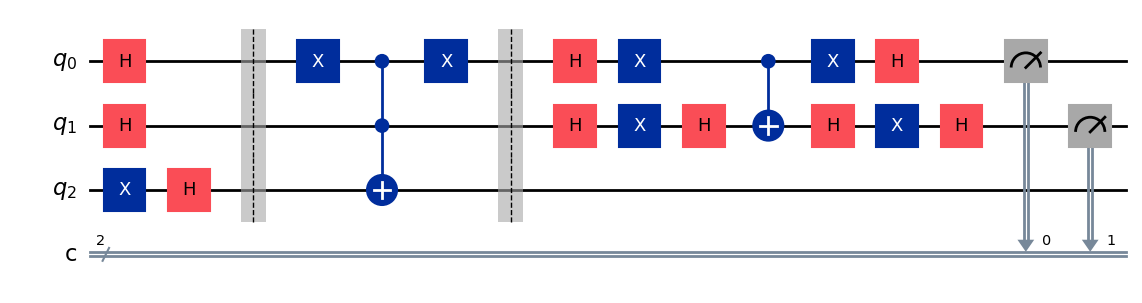

In [23]:
circuit_2q.draw('mpl')

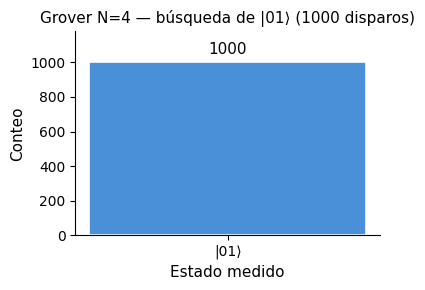

In [24]:
from qml_santanu.common.plot_utils import plot_counts

plot_counts(counts_2q, title='Grover N=4 — búsqueda de |01⟩')

### Verificación: los 4 posibles ganadores con $N = 4$

In [25]:
for elemento in ['00', '01', '10', '11']:
    _, result = grovers_algorithm(
        num_qubits=2, copies=500, secret_element=elemento,
    )
    recuperado = max(result, key=result.get)
    correcto = recuperado == elemento
    print(f"  Medido: |{recuperado}⟩  {'✓' if correcto else '✗'}")

Elemento buscado:  |00⟩
N = 4, n = 2, iteraciones de Grover = 1
  Medido: |00⟩  ✓
Elemento buscado:  |01⟩
N = 4, n = 2, iteraciones de Grover = 1
  Medido: |01⟩  ✓
Elemento buscado:  |10⟩
N = 4, n = 2, iteraciones de Grover = 1
  Medido: |10⟩  ✓
Elemento buscado:  |11⟩
N = 4, n = 2, iteraciones de Grover = 1
  Medido: |11⟩  ✓


---
## Caso 2: $N = 8$ (3 qubits) — oráculo más complejo

Con $N = 8$: $\theta \approx 20.7°$, se necesitan **2 iteraciones** para alcanzar $\approx 94.5\%$ de probabilidad.

Ahora el oráculo usa `mcx` con 3 controles (equivalente a un Toffoli de 3 entradas, llamado C³X). El difusor también escala: usa `mcx` con 2 controles para el flip de fase condicional.

Buscaremos el elemento $\vert 101\rangle$ (= 5 en decimal) entre 8 posibles.

In [26]:
circuit_3q, counts_3q = grovers_algorithm(
    num_qubits=3, copies=1000, secret_element='101',
)
print(f"\nResultados: {dict(sorted(counts_3q.items()))}")

Elemento buscado:  |101⟩
N = 8, n = 3, iteraciones de Grover = 2

Resultados: {'000': 8, '001': 8, '010': 11, '011': 5, '100': 15, '101': 938, '110': 5, '111': 10}


In [27]:
print(circuit_3q.draw(output='text'))

     ┌───┐      ░                 ░ ┌───┐┌───┐          ┌───┐┌───┐      ░      »
q_0: ┤ H ├──────░────────■────────░─┤ H ├┤ X ├───────■──┤ X ├┤ H ├──────░──────»
     ├───┤      ░ ┌───┐  │  ┌───┐ ░ ├───┤├───┤       │  ├───┤├───┤      ░ ┌───┐»
q_1: ┤ H ├──────░─┤ X ├──■──┤ X ├─░─┤ H ├┤ X ├───────■──┤ X ├┤ H ├──────░─┤ X ├»
     ├───┤      ░ └───┘  │  └───┘ ░ ├───┤├───┤┌───┐┌─┴─┐├───┤├───┤┌───┐ ░ └───┘»
q_2: ┤ H ├──────░────────■────────░─┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├─░──────»
     ├───┤┌───┐ ░      ┌─┴─┐      ░ └───┘└───┘└───┘└───┘└───┘└───┘└───┘ ░      »
q_3: ┤ X ├┤ H ├─░──────┤ X ├──────░─────────────────────────────────────░──────»
     └───┘└───┘ ░      └───┘      ░                                     ░      »
c: 3/══════════════════════════════════════════════════════════════════════════»
                                                                               »
«                ░ ┌───┐┌───┐          ┌───┐┌───┐     ┌─┐      
«q_0: ──■────────░─┤ H ├┤ X ├───────■──┤ X ├┤

### Visualización del circuito de 3 qubits

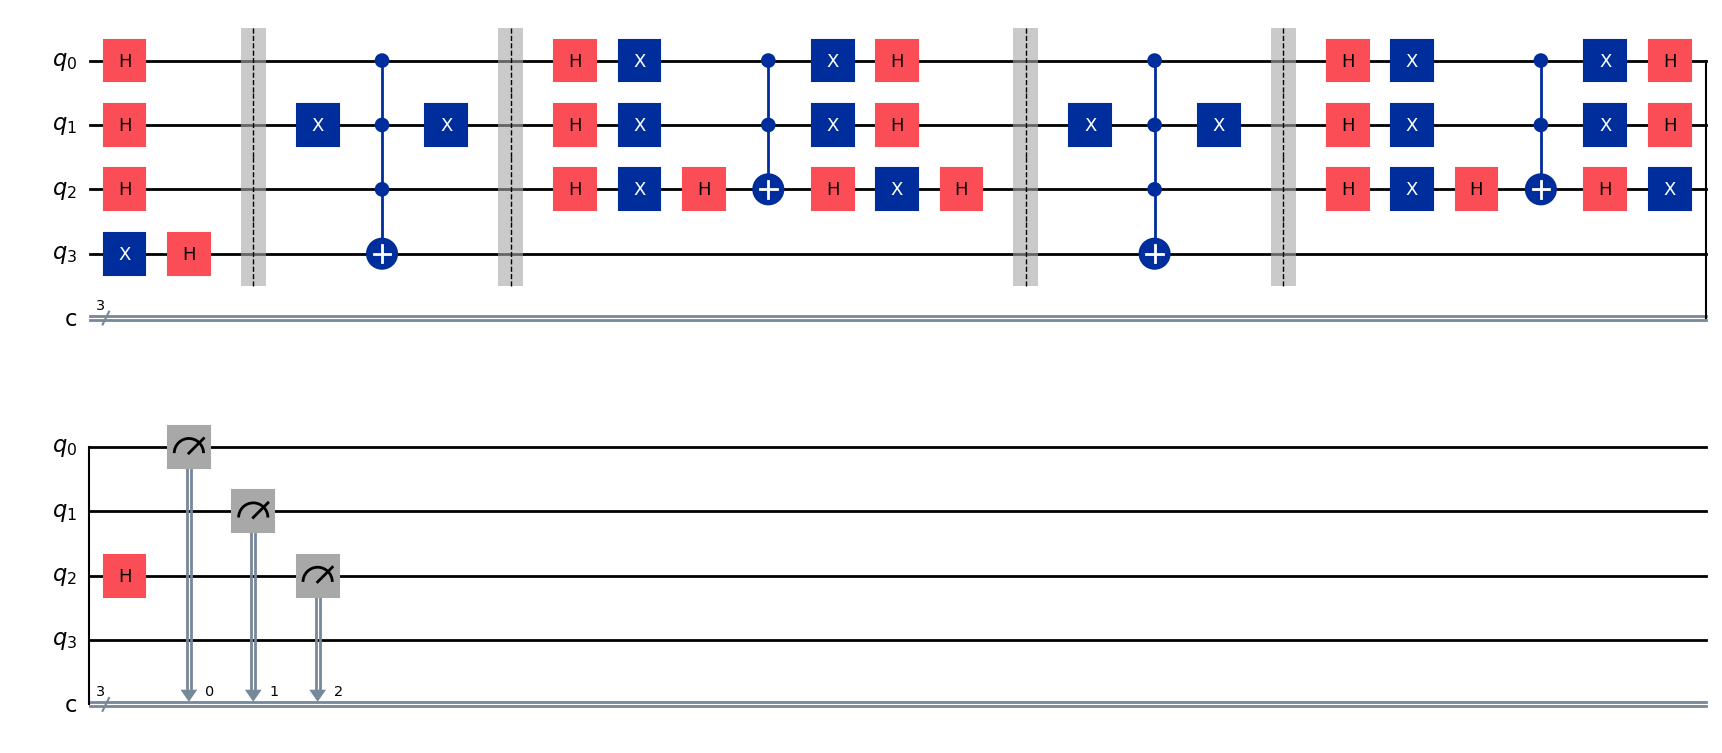

In [28]:
circuit_3q.draw('mpl')

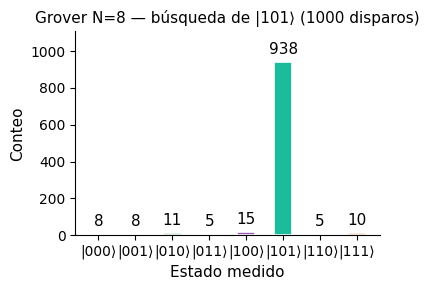

In [29]:
plot_counts(counts_3q, title='Grover N=8 — búsqueda de |101⟩')

### Verificación: varios ganadores con $N = 8$

In [30]:
for elemento in ['000', '011', '101', '110', '111']:
    _, result = grovers_algorithm(
        num_qubits=3, copies=500, secret_element=elemento,
    )
    recuperado = max(result, key=result.get)
    prob = 100 * result.get(elemento, 0) / sum(result.values())
    correcto = recuperado == elemento
    print(f"  Medido: |{recuperado}⟩  P={prob:.1f}%  {'✓' if correcto else '✗'}")

Elemento buscado:  |000⟩
N = 8, n = 3, iteraciones de Grover = 2
  Medido: |000⟩  P=94.0%  ✓
Elemento buscado:  |011⟩
N = 8, n = 3, iteraciones de Grover = 2
  Medido: |011⟩  P=94.0%  ✓
Elemento buscado:  |101⟩
N = 8, n = 3, iteraciones de Grover = 2
  Medido: |101⟩  P=94.8%  ✓
Elemento buscado:  |110⟩
N = 8, n = 3, iteraciones de Grover = 2
  Medido: |110⟩  P=95.4%  ✓
Elemento buscado:  |111⟩
N = 8, n = 3, iteraciones de Grover = 2
  Medido: |111⟩  P=94.6%  ✓


---
## Caso 3: $N = 16$ (4 qubits) — escalando más

Con $N = 16$: $\theta \approx 14.5°$, se necesitan **3 iteraciones**.

El oráculo ahora usa `mcx` con 4 controles y el difusor con 3. Buscamos $\vert 1010\rangle$.

In [31]:
circuit_4q, counts_4q = grovers_algorithm(
    num_qubits=4, copies=1000, secret_element='1010',
)
print(f"\nResultados: {dict(sorted(counts_4q.items()))}")

Elemento buscado:  |1010⟩
N = 16, n = 4, iteraciones de Grover = 3

Resultados: {'0000': 2, '0001': 2, '0010': 5, '0011': 3, '0100': 1, '0101': 2, '0110': 1, '1000': 2, '1010': 973, '1011': 1, '1100': 1, '1110': 5, '1111': 2}


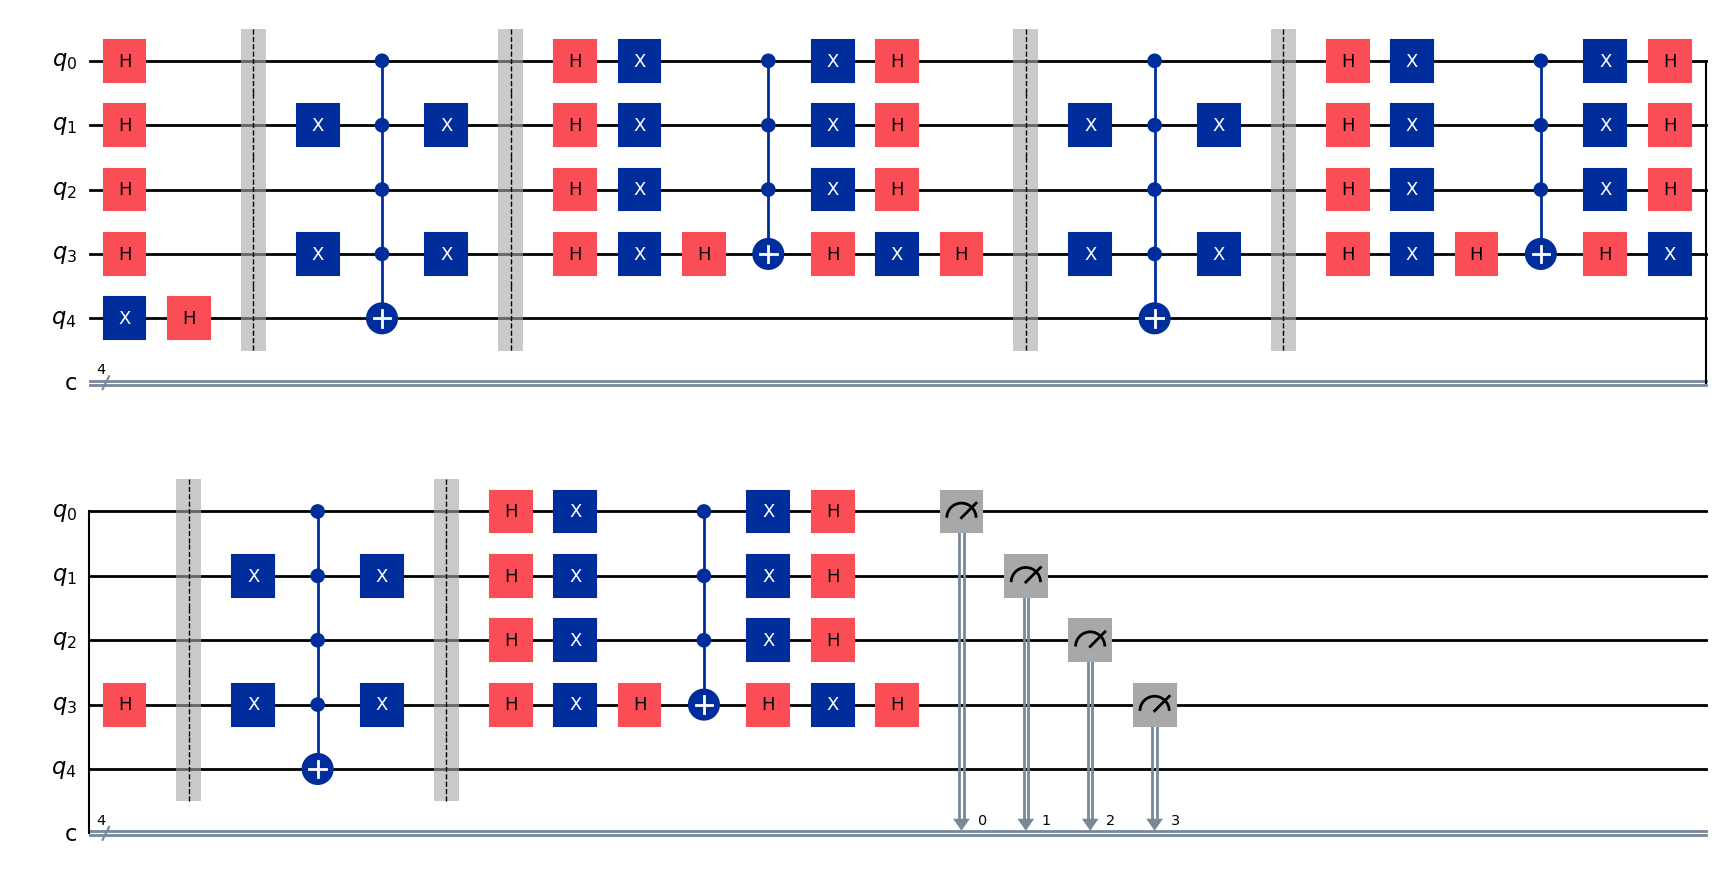

In [32]:
circuit_4q.draw('mpl')

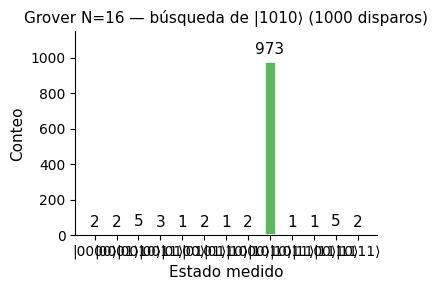

In [33]:
plot_counts(counts_4q, title='Grover N=16 — búsqueda de |1010⟩')

---
## Comparación: distribución uniforme vs Grover para $N = 4, 8, 16$

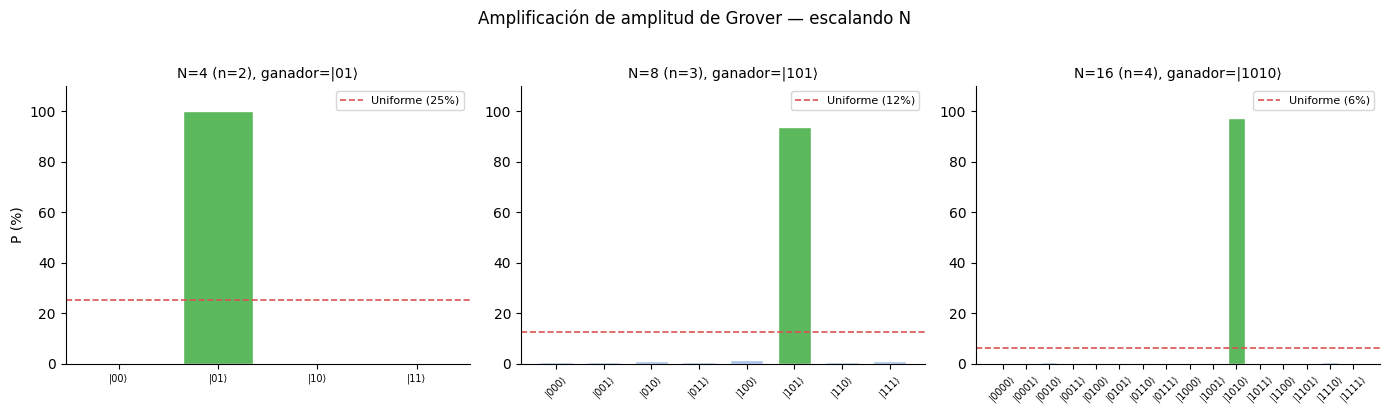

In [34]:
import matplotlib.pyplot as plt

casos = [
    (2, '01',   counts_2q),
    (3, '101',  counts_3q),
    (4, '1010', counts_4q),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (n, ganador, counts) in zip(axes, casos, strict=True):
    N = 2 ** n
    total = sum(counts.values())
    estados = [format(i, f'0{n}b') for i in range(N)]

    probs_grover = [100 * counts.get(e, 0) / total for e in estados]
    prob_uniforme = 100 / N

    colores = [
        '#5cb85c' if e == ganador else '#aac4e8'
        for e in estados
    ]

    ax.bar(range(N), probs_grover, color=colores, edgecolor='white', width=0.7)
    ax.axhline(
        prob_uniforme, color='#d9534f', linestyle='--', linewidth=1.2,
        label=f'Uniforme ({prob_uniforme:.0f}%)',
    )

    ax.set_title(f'N={N} (n={n}), ganador=|{ganador}⟩', fontsize=10)
    ax.set_ylabel('P (%)' if n == 2 else '', fontsize=10)
    ax.set_ylim(0, 110)
    ax.set_xticks(range(N))
    ax.set_xticklabels(
        [f'|{e}⟩' for e in estados],
        fontsize=7, rotation=45 if n >= 3 else 0,
    )
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    'Amplificación de amplitud de Grover — escalando N',
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.show()

---

## Conclusión

### Lo que observamos al escalar

| $n$ | $N$ | Iteraciones | $P(\text{ganador})$ | Observación |
|:---:|:---:|:---:|:---:|---|
| 2 | 4 | 1 | $\approx 100\%$ | Convergencia perfecta |
| 3 | 8 | 2 | $\approx 94.5\%$ | Se empieza a ver ruido residual |
| 4 | 16 | 3 | $\approx 96\%$ | El ganador domina pero otros estados aparecen |

A medida que $N$ crece, el ganador sigue dominando ampliamente, pero la probabilidad ya no es exactamente 100% porque el ángulo $\theta$ no divide $90°$ de forma exacta.

### Diferencias clave con la implementación en Cirq

| Aspecto | Cirq | Qiskit |
|---|---|---|
| Toffoli generalizado | `cirq.TOFFOLI` (solo 2 controles) | `circuit.mcx(controls, target)` — $n$ controles |
| Difusor | Hardcodeado con CNOT para 2 qubits | Generalizado con `mcx` para $n$ qubits |
| Orden de bits | Natural (Q0 = bit 0) | Invertido (MSB primero) → requiere `[::-1]` |
| Iteraciones | 1 (fija en el libro) | Calculada con $\lfloor \frac{\pi}{4}\sqrt{N} \rfloor$ |

### ¿Qué hace diferente al oráculo cuando $n$ crece?

Con 2 qubits, el oráculo usa un Toffoli estándar (2 controles → 1 blanco). Con 3 qubits necesita un C³X (3 controles) y con 4 un C⁴X (4 controles). Internamente Qiskit descompone estos `mcx` en secuencias de Toffoli y ancillas — el circuito transpilado crece, pero la lógica es la misma.

---

## Discusión: aplicaciones reales y limitaciones de Grover

### 1. Ataque de fuerza bruta a cifrado simétrico (AES)

La aplicación más directa y estudiada de Grover es la búsqueda exhaustiva de claves criptográficas. El oráculo es conceptualmente simple: toma una clave candidata, descifra el mensaje, y responde 1 si el resultado es válido.

| Cifrado | Claves posibles | Clásico (fuerza bruta) | Con Grover | Seguridad efectiva |
|---|:---:|:---:|:---:|:---:|
| AES-128 | $2^{128}$ | $O(2^{128})$ | $O(2^{64})$ | 64 bits |
| AES-256 | $2^{256}$ | $O(2^{256})$ | $O(2^{128})$ | 128 bits |

Grassl et al. (2016) implementaron el oráculo de Grover para AES como circuito cuántico y estimaron los recursos necesarios. La conclusión práctica: AES-128 pierde la mitad de su seguridad, por lo que la **recomendación post-cuántica del NIST es usar AES-256** — con Grover queda en 128 bits efectivos, que sigue siendo seguro.

> **Referencia:** Grassl, M. et al. (2016). *Applying Grover's Algorithm to AES: Quantum Resource Estimates.* [IACR ePrint 2019/1146](https://eprint.iacr.org/2019/1146.pdf)

### 2. Satisfacibilidad booleana (SAT)

Dado un sistema de restricciones lógicas con $n$ variables, encontrar una asignación que las satisfaga requiere explorar hasta $2^n$ combinaciones. Grover reduce esto a $O(2^{n/2})$.

- **Oráculo**: evalúa la fórmula booleana → 1 si la asignación la satisface
- **Aplicaciones**: planificación logística, scheduling, verificación de hardware, optimización combinatoria

### 3. El mito de la "búsqueda en base de datos"

El ejemplo más citado — buscar en una base de datos no ordenada — es **engañoso**. En el modelo de circuitos, cada iteración de Grover necesita "tocar" cada elemento de la base, resultando en complejidad de puertas $O(N^{3/2})$, que es **peor** que recorrer la base secuencialmente con $O(N)$.

La ventaja cuadrática solo se recupera si se asume acceso a una **qRAM** (memoria de acceso aleatorio cuántico) con costo $O(\log N)$ por consulta — y construir qRAM escalable sigue siendo un problema abierto en hardware cuántico.

> **Referencia:** Jaques, S. & Schanck, J.M. (2023). *Quantum algorithms: survey of applications and end-to-end complexities.* [arXiv:2310.03011](https://arxiv.org/pdf/2310.03011)

### 4. La optimalidad demostrada

Bennett, Bernstein, Brassard y Vazirani (1997) demostraron que $\Omega(\sqrt{N})$ consultas es un **límite inferior cuántico** para búsqueda no estructurada — conocido como el **teorema BBBV**. Notablemente, este resultado fue publicado *antes* de que Grover descubriera su algoritmo.

Posteriormente, Zalka (1999) demostró que Grover es **exactamente óptimo**: ningún algoritmo cuántico puede hacerlo mejor ni siquiera por factores constantes.

> **Referencias:**  
> - Bennett, C.H. et al. (1997). *Strengths and Weaknesses of Quantum Computing.* SIAM Journal on Computing.  
> - Zalka, C. (1999). *Grover's quantum searching algorithm is optimal.* [arXiv:quant-ph/9711070](https://arxiv.org/pdf/0810.3647)  
> - Aaronson, S. *Lecture 23: BBBV, Applications of Grover.* [Notas del curso](https://www.scottaaronson.com/qclec/23.pdf)

### 5. Limitación clave: no paraleliza bien

Zalka también demostró que Grover no se beneficia de la paralelización de forma eficiente: se necesitan $S^2$ computadoras cuánticas para encontrar la clave $S$ veces más rápido. Esto limita severamente el ataque práctico a criptografía simétrica.

### Resumen: qué hace y qué no hace Grover en la práctica

| Afirmación | ¿Correcta? | Matiz |
|---|:---:|---|
| Grover rompe AES-128 | Parcial | Reduce seguridad a 64 bits — insuficiente, pero AES-256 sigue seguro |
| Grover busca en bases de datos más rápido | **No** | Solo con qRAM, que no existe en hardware real |
| Grover da ventaja exponencial | **No** | La ventaja es cuadrática ($\sqrt{N}$), no exponencial ($\log N$) |
| Grover es útil como subrutina | **Sí** | Amplificación de amplitud aparece en quantum k-means, SVM cuántico, y minimización cuántica |
| Ningún algoritmo cuántico puede mejorar a Grover | **Sí** | Demostrado formalmente por BBBV (1997) y Zalka (1999) |